# 5. Choosing model settings

**What this shows:** how the startup, physics and numerics components set up a SWAN
run, what SWAN does when a command is left out, and how much two common physics
choices change the results.

**Prerequisites:** [4. Wave boundaries](04_wave_boundaries.ipynb).

**You will learn:**

- what `PROJECT`, `SET`, `MODE` and `COORDINATES` control
- which physical processes SWAN includes by default, and how to add or change them
- what the numerics settings do
- which checks rompy-swan applies before SWAN runs

**Data used:** `etopo15s_perth.nc` (bathymetry), `era5-20230101.nc` (winds) and
`ww3-spectra-20230101-short.nc` (boundary spectra).

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from pydantic import ValidationError
from rompy.logging import config as logging_config

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "05_model_settings"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. Startup

The startup commands come first in `INPUT`:

- `PROJECT`: a name and a run identifier `nr` (up to 4 characters), written to the
  output files;
- `SET`: general settings, e.g. the water `level` added to all depths, the minimum
  depth `depmin`, and the direction convention;
- `MODE`: stationary or nonstationary, one- or two-dimensional;
- `COORDINATES`: Cartesian or spherical.

In [2]:
from rompy_swan.components.group import STARTUP
from rompy_swan.components.startup import COORDINATES, MODE, PROJECT, SET
from rompy_swan.subcomponents.startup import SPHERICAL

startup = STARTUP(
    project=PROJECT(name="Model settings", nr="t05"),
    set=SET(level=0.0, depmin=0.05, direction_convention="nautical"),
    mode=MODE(kind="nonstationary", dim="twodimensional"),
    coordinates=COORDINATES(kind=SPHERICAL()),
)
print(startup.render())

PROJECT name='Model settings' nr='t05'

SET level=0.0 depmin=0.05 NAUTICAL

MODE NONSTATIONARY TWODIMENSIONAL

COORDINATES SPHERICAL CCM


## 2. Physics

SWAN's physics are the source terms that add, remove or move wave energy. When a
command is not given, SWAN uses its default:

| Process | SWAN default | rompy-swan component |
|---|---|---|
| Wind input and whitecapping | on, WESTHUYSEN package since SWAN 41.45 (KOMEN before) | `GEN3(source_terms=...)` |
| Four-wave (quadruplet) interactions | on | `QUADRUPL`, or `OFF` to switch off |
| Depth-induced breaking | on, constant `alpha=1`, `gamma=0.73` | `BREAKING_CONSTANT`, `BREAKING_BKD` |
| Bottom friction | **off** | `FRICTION_JONSWAP`, `FRICTION_COLLINS`, `FRICTION_MADSEN` |
| Three-wave (triad) interactions | **off** | `TRIAD`, `TRIAD_DCTA` |

rompy-swan only writes the commands you set. Bottom friction and triads matter in
shallow water, so coastal models usually switch them on.

In [3]:
from rompy_swan.components.group import PHYSICS
from rompy_swan.components.physics import BREAKING_CONSTANT, FRICTION_JONSWAP, GEN3, TRIAD
from rompy_swan.subcomponents.physics import WESTHUYSEN

physics = PHYSICS(
    gen=GEN3(source_terms=WESTHUYSEN()),
    breaking=BREAKING_CONSTANT(alpha=1.0, gamma=0.73),
    friction=FRICTION_JONSWAP(cfjon=0.038),
    triad=TRIAD(),
)
print(physics.render())

GEN3 WESTHUYSEN DRAG WU

BREAKING CONSTANT alpha=1.0 gamma=0.73

FRICTION JONSWAP CONSTANT cfjon=0.038

TRIAD


[Physics](../examples/physics.ipynb) covers the other source-term packages (KOMEN,
ST6), breaking and friction options, set-up, obstacles and vegetation.

## 3. Numerics

- `PROP` chooses the propagation scheme. SWAN's default depends on the mode; `BSBT`
  (first order) is robust with large time steps or coarse grids.
- `NUMERIC` sets how SWAN decides that an iteration has converged (`STOPC`) and how
  many iterations it may use.

In [4]:
from rompy_swan.components.numerics import NUMERIC, PROP
from rompy_swan.subcomponents.numerics import BSBT, STOPC

prop = PROP(scheme=BSBT())
numeric = NUMERIC(stop=STOPC(dabs=0.005, drel=0.01, curvat=0.005, npnts=99.5))
print(prop.render())
print(numeric.render())

PROP BSBT
NUMERIC STOPC dabs=0.005 drel=0.01 curvat=0.005 npnts=99.5


[Numerics](../examples/numerics.ipynb) explains these options and the time-step
guidance from the SWAN manual.

## 4. Checks before SWAN runs

Each component checks its own values, and `SwanConfig` checks that they fit together.
A few examples:

In [5]:
from rompy_swan.components.output import POINTS

try:
    PROJECT(nr="run01")
except ValidationError as err:
    print(err)

1 validation error for PROJECT
nr
  String should have at most 4 characters [type=string_too_long, input_value='run01', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/string_too_long


In [6]:
try:
    POINTS(sname="offshore_buoy", xp=[115.0], yp=[-32.0])
except ValidationError as err:
    print(err)

1 validation error for POINTS
sname
  String should have at most 8 characters [type=string_too_long, input_value='offshore_buoy', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/string_too_long


Messages point at the field and the rule. Tutorials 3 and 4 showed a check across
components: time-varying inputs in stationary mode.

## 5. How much do the settings matter?

We compare two versions of the model at 15:00, with the wind of Tutorial 3 and the
boundary spectra of Tutorial 4: SWAN's default physics, and the physics above, which
add bottom friction and triads.

In [7]:
from rompy.core.filters import Filter
from rompy.core.source import SourceFile, SourceWavespectra
from rompy.core.time import TimeRange
from rompy_swan.boundary import Boundnest1
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.components.group import LOCKUP, OUTPUT
from rompy_swan.components.lockup import COMPUTE_STAT
from rompy_swan.components.output import BLOCK
from rompy_swan.config import SwanConfig
from rompy_swan.data import SwanDataGrid
from rompy_swan.grid import SwanGrid
from rompy_swan.interface import BoundaryInterface, DataInterface
from rompy_swan.subcomponents.spectrum import SPECTRUM

grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
period = TimeRange(start="2023-01-01T15:00", end="2023-01-01T16:00", interval="1h")
inpgrid = DataInterface(
    bottom=SwanDataGrid(
        var="bottom",
        source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
        z1="z",
        fac=-1.0,
        coords={"x": "longitude", "y": "latitude"},
        buffer=0.1,
    ),
    input=[
        SwanDataGrid(
            var="wind",
            source=SourceFile(uri=DATA_DIR / "era5-20230101.nc"),
            z1="u10",
            z2="v10",
            coords={"x": "longitude", "y": "latitude"},
            filter=Filter(sort={"coords": ["latitude"]}),
            buffer=0.25,
        )
    ],
)
boundary = BoundaryInterface(
    kind=Boundnest1(
        id="ww3",
        source=SourceWavespectra(
            uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
        ),
        sel_method="idw",
        sel_method_kwargs={"tolerance": 1.5},
        spacing=0.1,
    )
)


def swan_config(physics: PHYSICS) -> SwanConfig:
    """The stationary model at 15:00 with the given physics."""
    return SwanConfig(
        startup=startup,
        cgrid=REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0)),
        inpgrid=inpgrid,
        boundary=boundary,
        physics=physics,
        output=OUTPUT(
            block=BLOCK(sname="COMPGRID", fname="swangrid.nc", output=["depth", "hsign"])
        ),
        lockup=LOCKUP(compute=COMPUTE_STAT()),
    )


configs = {"default": swan_config(PHYSICS(gen=GEN3())), "coastal": swan_config(physics)}

In [8]:
from rompy.backends import DockerConfig
from rompy.model import ModelRun


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
results = {}
for name, config in configs.items():
    modelrun = ModelRun(run_id=name, period=period, output_dir=OUT_DIR, config=config)
    workspace = Path(modelrun())
    if docker_available() and modelrun.run(backend, workspace_dir=workspace):
        results[name] = xr.open_dataset(workspace / "swangrid.nc").isel(time=0)
print(f"Runs completed: {list(results)}")

Runs completed: ['default', 'coastal']


Offshore the two agree, because friction and triads act in shallow water. Near the
coast and over the shallow banks, the wave height drops by up to 0.6 m, about 30%.

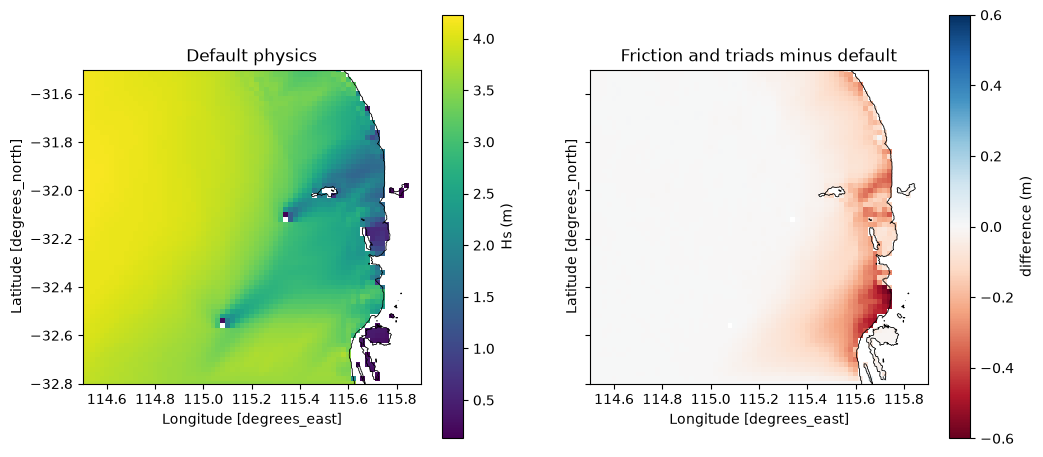

In [9]:
if len(results) == 2:
    diff = results["coastal"].hs - results["default"].hs
    etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
    results["default"].hs.plot(ax=axes[0], cmap="viridis", cbar_kwargs={"label": "Hs (m)"})
    diff.plot(ax=axes[1], cmap="RdBu", vmin=-0.6, vmax=0.6, cbar_kwargs={"label": "difference (m)"})
    for ax, title in zip(axes, ["Default physics", "Friction and triads minus default"]):
        etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
        ax.set(xlim=(114.5, 115.9), ylim=(-32.8, -31.5), title=title)
        ax.set_aspect("equal")

## Summary

- The startup group sets the run name, general settings, mode and coordinates.
- SWAN switches on wind input, whitecapping, quadruplets and breaking by default, but
  not bottom friction or triads; rompy-swan writes only what you set.
- `PROP` and `NUMERIC` control the propagation scheme and convergence.
- Settings are checked when the objects are created, before SWAN runs.

**Next:** [6. A nonstationary hindcast](06_nonstationary_hindcast.ipynb).